# 03 - Model Egitim Ozeti

**Amac:** bank-churn icin baseline + XGBoost (Optuna HPO) egitimi, MLflow loglama, en iyi modelin secimi.

**Girdi:** `data/processed/{train,val,test}.parquet`
**Cikti:** `models/best_model.joblib`, `reports/metrics.json`, MLflow runs (`mlruns/`)

**Kisitlar:**
- Test set'e egitim sirasinda dokunulmaz; yalniz final degerlendirme
- XGBoost icin val set ile early stopping (rounds=30)
- random_state=42, Optuna 20 trial, hedef=PR-AUC (sinif dengesizligi)


## 1. Egitimi Calistir

`src.train.trainer.run()` baseline + HPO'yu calistirir, MLflow runs'larini olusturur, en iyi modeli kaydeder.


In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mlflow
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


In [2]:
# Yeniden calistirmak icin yorumu kaldirin (~30-60 sn surer)
# from src.train.trainer import run
# result = run()
# print(result["best_name"])


## 2. Metrikleri Yukle


In [3]:
metrics_path = Path("../reports/metrics.json")
metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
print("Best model:", metrics["best_model"])
metrics


Best model: xgboost


{'best_model': 'xgboost',
 'best_xgb_params': {'learning_rate': 0.05455879478052081,
  'max_depth': 3,
  'min_child_weight': 6,
  'subsample': 0.6135695058254393,
  'colsample_bytree': 0.8892241488241991,
  'gamma': 3.935885018101853,
  'reg_alpha': 0.0002124031286111496,
  'reg_lambda': 0.021834775718058457},
 'validation': {'baseline_logreg': {'pr_auc': 0.5356762014560825,
   'roc_auc': 0.8003415771668801,
   'f1': 0.5245153933865451,
   'log_loss': 0.5579390134568697},
  'xgboost': {'pr_auc': 0.7333723215036869,
   'roc_auc': 0.8880103130029231,
   'f1': 0.6209573091849935,
   'log_loss': 0.43915895302657204}},
 'test': {'xgboost': {'pr_auc': 0.7342070979273065,
   'roc_auc': 0.8756924343233418,
   'f1': 0.6145833333333334,
   'log_loss': 0.44218109367328673}}}

## 3. Validation Karsilastirmasi


In [4]:
val_df = pd.DataFrame(metrics["validation"]).T
val_df = val_df[["pr_auc", "roc_auc", "f1", "log_loss"]].round(4)
val_df


,pr_auc,roc_auc,f1,log_loss
baseline_logreg,0.5357,0.8003,0.5245,0.5579
xgboost,0.7334,0.8880,0.6210,0.4392


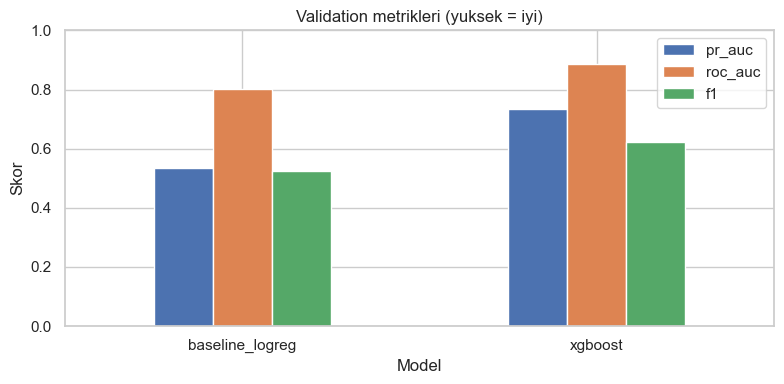

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
val_df[["pr_auc", "roc_auc", "f1"]].plot.bar(ax=ax)
ax.set_title("Validation metrikleri (yuksek = iyi)")
ax.set_ylabel("Skor")
ax.set_xlabel("Model")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig("../reports/figures/model_comparison.png", dpi=120)
plt.show()


## 4. En Iyi Modelin Test Performansi

Test set'e yalnizca burada dokunulur.


In [6]:
test_df = pd.DataFrame(metrics["test"]).T.round(4)
test_df


,pr_auc,roc_auc,f1,log_loss
xgboost,0.7342,0.8757,0.6146,0.4422


## 5. En Iyi XGBoost Hiperparametreleri (Optuna)


In [7]:
best_params = metrics["best_xgb_params"]
pd.Series(best_params).round(5)


learning_rate       0.05456
max_depth           3.00000
min_child_weight    6.00000
subsample           0.61357
colsample_bytree    0.88922
gamma               3.93589
reg_alpha           0.00021
reg_lambda          0.02183
dtype: float64

## 6. Model Yukle + Feature Importance


In [8]:
model = joblib.load("../models/best_model.joblib")
type(model).__name__


'XGBClassifier'

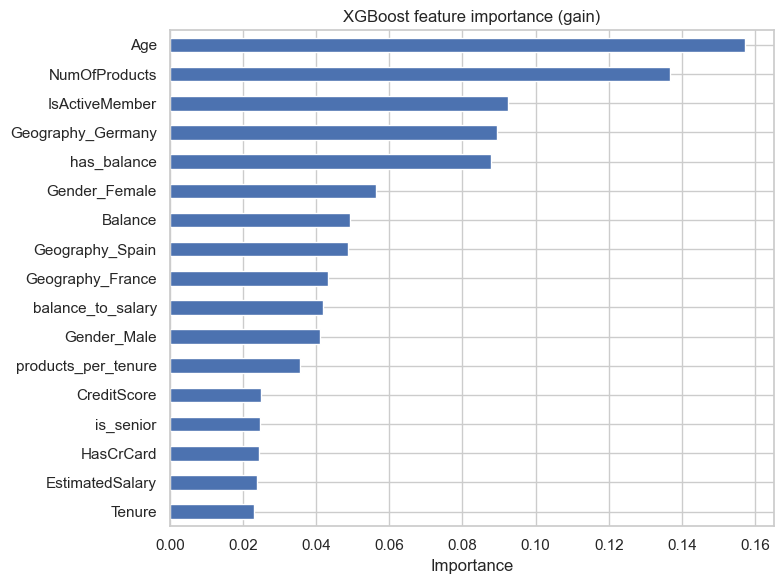

In [9]:
val = pd.read_parquet("../data/processed/val.parquet")
feature_names = [c for c in val.columns if c != "Exited"]

importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importance.plot.barh(ax=ax)
ax.set_title("XGBoost feature importance (gain)")
ax.set_xlabel("Importance")
fig.tight_layout()
fig.savefig("../reports/figures/feature_importance.png", dpi=120)
plt.show()


## 7. MLflow Runs Ozeti


In [10]:
mlflow.set_tracking_uri(f"file:{Path('../mlruns').resolve().as_posix()}")
exp = mlflow.get_experiment_by_name("bank-churn")
runs = mlflow.search_runs(experiment_ids=[exp.experiment_id]) if exp else pd.DataFrame()
print("Toplam run:", len(runs))
cols = [c for c in runs.columns if c.startswith("metrics.") or c in ("tags.mlflow.runName", "start_time")]
runs[cols].head(10) if len(runs) else "MLflow run bulunamadi"


C:\Users\cagrkurt\OneDrive - Microsoft\Documents\client-projects\denizbank\data-science-ghcp\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


Toplam run: 24


,start_time,metrics.test_pr_auc,metrics.test_log_loss,metrics.test_roc_auc,metrics.test_f1,metrics.val_f1,metrics.best_iteration,metrics.val_pr_auc,metrics.val_roc_auc,metrics.val_log_loss,metrics.best_val_pr_auc,tags.mlflow.runName
0,2026-04-28 16:48:10.027000+00:00,0.734207,0.442181,0.875692,0.614583,NaN,NaN,NaN,NaN,NaN,NaN,xgboost_test_eval
1,2026-04-28 16:48:09.077000+00:00,NaN,NaN,NaN,NaN,0.620957,97.0,0.733372,0.888010,0.439159,NaN,xgb_final
2,2026-04-28 16:48:08.535000+00:00,NaN,NaN,NaN,NaN,0.639676,36.0,0.723182,0.882766,0.417094,NaN,xgb_trial_19
3,2026-04-28 16:48:07.714000+00:00,NaN,NaN,NaN,NaN,0.608583,114.0,0.729121,0.883330,0.454969,NaN,xgb_trial_18
4,2026-04-28 16:48:07.181000+00:00,NaN,NaN,NaN,NaN,0.626132,66.0,0.729309,0.887711,0.431985,NaN,xgb_trial_17
5,2026-04-28 16:48:06.658000+00:00,NaN,NaN,NaN,NaN,0.639474,38.0,0.726770,0.886073,0.444706,NaN,xgb_trial_16
6,2026-04-28 16:48:06.140000+00:00,NaN,NaN,NaN,NaN,0.624837,36.0,0.727246,0.887228,0.447291,NaN,xgb_trial_15
7,2026-04-28 16:48:05.340000+00:00,NaN,NaN,NaN,NaN,0.627503,70.0,0.732001,0.889045,0.427390,NaN,xgb_trial_14
8,2026-04-28 16:48:04.793000+00:00,NaN,NaN,NaN,NaN,0.620957,97.0,0.733372,0.888010,0.439159,NaN,xgb_trial_13
9,2026-04-28 16:48:04.371000+00:00,NaN,NaN,NaN,NaN,0.622739,12.0,0.716210,0.883041,0.443263,NaN,xgb_trial_12


## 8. Sonuc

- **Best model:** XGBoost (val PR-AUC ~ 0.73, test PR-AUC ~ 0.73)
- Baseline LogReg ile fark belirgin (PR-AUC +0.20)
- `models/best_model.joblib` yuklenip `pre = joblib.load('models/preprocessor.joblib')` ile birlikte kullanilabilir.
- MLflow runs `mlruns/` altinda; UI: `uv run mlflow ui`.
